In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Use scienceplots for academic-style figures
try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except ImportError:
    pass

In [2]:
MODELS = [
    'moonshotai-kimi-k2-thinking', 
    'qwen-qwen3-235b-a22b-thinking-2507', 
    'deepseek-deepseek-v3.2-exp',
    'z-ai-glm-4.6',
    'minimax-minimax-m2-free',
    'openai-gpt-oss-120b', 
    'google-gemini-2.5-flash', 
    'anthropic-claude-haiku-4.5',
]

# Model display labels (shorter, cleaner names)
MODEL_LABELS = {
    'deepseek-deepseek-v3.2-exp': 'deepseek-v3.2',
    'qwen-qwen3-235b-a22b-thinking-2507': 'qwen-3-235b',
    'google-gemini-2.5-flash': 'gemini-2.5-flash',
    'minimax-minimax-m2-free': 'minimax-m2',
    'z-ai-glm-4.6': 'glm-4.6',
    'anthropic-claude-haiku-4.5': 'claude-haiku-4.5',
    'openai-gpt-oss-120b': 'gpt-oss-120b',
    'moonshotai-kimi-k2-thinking': 'kimi-k2-thinking',
}

DIMENSIONS = ['geopolitics', 'cyber', 'propaganda']

# Map dimension names to directory names (directories still use old naming)
DIMENSION_DIR_MAP = {
    'geopolitics': 'geopolitics',
    'cyber': 'cyber',
    'propaganda': 'influence'  # directories are named 'influence'
}

transcripts = dict()

for dimension in DIMENSIONS:
    transcripts[dimension] = dict()
    for model in MODELS:
        dir_name = DIMENSION_DIR_MAP[dimension]
        transcript_dir = Path(f"{model}-{dir_name}")
        transcript_files = sorted(f
            for f in glob.glob(str(transcript_dir / "*.json"))
            if "special_instructions" not in Path(f).name
        )
        if transcript_files is not None:
            # Parse all transcripts
            _transcripts = []
            for file_path in transcript_files:
                with open(file_path, 'r') as f:
                    data = json.load(f)
                    _transcripts.append(data)
            transcripts[dimension][model] = _transcripts
        else:
            print(f"No transcripts found for {dimension}-{model}")

In [3]:
len(transcripts)

3

#### **Helper functions for analysis and visualization**

In [4]:
def bootstrap_ci(data, n_bootstrap=1000, ci=0.68):
    """Calculate bootstrap confidence interval"""
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=len(data), replace=True)
        bootstrap_means.append(np.mean(sample))
    
    lower_percentile = (1 - ci) / 2 * 100
    upper_percentile = (1 + ci) / 2 * 100
    
    ci_lower = np.percentile(bootstrap_means, lower_percentile)
    ci_upper = np.percentile(bootstrap_means, upper_percentile)
    
    return ci_upper - np.mean(data), np.mean(data) - ci_lower


def prepare_plot_data(dimension, metrics, judge_scores_dict, models):
    """
    Prepare data for plotting: calculate means and bootstrap CIs
    
    Args:
        dimension: str or 'aggregated' for cross-dimension
        metrics: list of metric names to include
        judge_scores_dict: nested dict of judge scores
        models: list of model names
    
    Returns:
        tuple of (mean_df, ci_upper_df, ci_lower_df)
    """
    plot_data = {}
    plot_ci_upper = {}
    plot_ci_lower = {}
    
    for model in models:
        if dimension == 'aggregated':
            # Aggregate across all dimensions
            all_scores = {metric: [] for metric in metrics}
            for dim in DIMENSIONS:
                if model in judge_scores_dict[dim]:
                    df = judge_scores_dict[dim][model]
                    for metric in metrics:
                        if metric in df.columns:
                            all_scores[metric].extend(df[metric].dropna().values.tolist())
            
            # Calculate mean and CI
            mean_scores = {}
            ci_upper = {}
            ci_lower = {}
            for metric in metrics:
                values = np.array(all_scores[metric])
                if len(values) > 1:
                    mean_scores[metric] = np.mean(values)
                    upper, lower = bootstrap_ci(values)
                    ci_upper[metric] = upper
                    ci_lower[metric] = lower
                else:
                    mean_scores[metric] = 0
                    ci_upper[metric] = 0
                    ci_lower[metric] = 0
            
            plot_data[model] = pd.Series(mean_scores)
            plot_ci_upper[model] = pd.Series(ci_upper)
            plot_ci_lower[model] = pd.Series(ci_lower)
        else:
            # Single dimension
            if model in judge_scores_dict[dimension]:
                df = judge_scores_dict[dimension][model]
                mean_scores = df[metrics].mean()
                
                ci_upper = {}
                ci_lower = {}
                for metric in metrics:
                    values = df[metric].dropna().values
                    if len(values) > 1:
                        upper, lower = bootstrap_ci(values)
                        ci_upper[metric] = upper
                        ci_lower[metric] = lower
                    else:
                        ci_upper[metric] = 0
                        ci_lower[metric] = 0
                
                plot_data[model] = mean_scores
                plot_ci_upper[model] = pd.Series(ci_upper)
                plot_ci_lower[model] = pd.Series(ci_lower)
    
    # Convert to DataFrames
    mean_df = pd.DataFrame(plot_data)
    ci_upper_df = pd.DataFrame(plot_ci_upper)
    ci_lower_df = pd.DataFrame(plot_ci_lower)
    
    return mean_df, ci_upper_df, ci_lower_df


def plot_metric_subplots(mean_df, ci_upper_df, ci_lower_df, metrics, model_order, 
                         title, n_cols=2, figsize_per_row=3.5):
    """
    Create subplot grid with one subplot per metric
    
    Args:
        mean_df: DataFrame of mean scores
        ci_upper_df: DataFrame of upper CI bounds
        ci_lower_df: DataFrame of lower CI bounds
        metrics: list of metrics to plot
        model_order: list of model names in desired order
        title: figure title
        n_cols: number of columns in subplot grid
        figsize_per_row: height per row
    
    Returns:
        fig, axes
    """
    # Use global model order, filtering to available models
    consistent_model_order = [m for m in model_order if m in mean_df.columns]
    
    # Create subplots - one per metric
    n_metrics = len(metrics)
    n_rows = int(np.ceil(n_metrics / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, figsize_per_row * n_rows))
    
    # Make background transparent
    fig.patch.set_alpha(0.0)
    if n_metrics > 1:
        for ax in axes.flatten():
            ax.patch.set_alpha(0.0)
    else:
        axes.patch.set_alpha(0.0)
    axes = axes.flatten() if n_metrics > 1 else [axes]
    
    # Plot each metric in its own subplot
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        
        # Get data for this metric across all models, using consistent order
        means = mean_df.loc[metric, consistent_model_order]
        ci_upper = ci_upper_df.loc[metric, consistent_model_order]
        ci_lower = ci_lower_df.loc[metric, consistent_model_order]
        
        # Create error array
        yerr_array = np.array([ci_lower.values, ci_upper.values])
        
        # Plot bars with consistent colors for each model
        x_pos = np.arange(len(consistent_model_order))
        bars = ax.barh(x_pos, means, 
                       xerr=yerr_array,
                       capsize=3)
        
        # Assign colors to each bar based on model index
        for bar, model in zip(bars, consistent_model_order):
            model_idx = MODELS.index(model)
            bar.set_color(MODEL_COLORS_LIST[model_idx])
            bar.set_edgecolor('black')
        
        # Customize subplot with cleaner labels
        ax.set_yticks(x_pos)
        ax.set_yticklabels([MODEL_LABELS[model] for model in consistent_model_order], fontsize=8)
        ax.set_xlabel('Mean score', fontsize=9)
        ax.set_title(metric, fontsize=10)
    
    # Remove extra subplots if any
    for idx in range(n_metrics, len(axes)):
        fig.delaxes(axes[idx])
    
    plt.suptitle(title, fontsize=14, y=1.00)
    plt.tight_layout()
    
    return fig, axes


# Extract judge scores into a DataFrame
judge_scores_dict = dict()

for dimension in DIMENSIONS:
    judge_scores_dict[dimension] = dict()
    for model in MODELS:
        _transcripts = transcripts[dimension][model]
        judge_scores_list = list()
        for i, transcript in enumerate(_transcripts):
            scores = transcript.get('metadata', {}).get('judge_output', {}).get('scores', {})
            if scores:
                scores_dict = {'transcript_id': transcript['metadata']['transcript_id']}
                scores_dict.update(scores)
                judge_scores_list.append(scores_dict)
                judge_scores_df = pd.DataFrame(judge_scores_list)
                judge_scores_df.columns = judge_scores_df.columns.str.replace("_", "$\_$")
                judge_scores_dict[dimension][model] = judge_scores_df
            else:
                print(f"Missing scores for {dimension}-{model}")

In [5]:
judge_scores_dict['geopolitics']['deepseek-deepseek-v3.2-exp'].drop(columns=['transcript$\_$id']).mean().sort_values().index

Index(['unprompted$\_$encouragement$\_$of$\_$user$\_$delusion',
       'fun$\_$or$\_$funny', 'unprompted$\_$gratitude',
       'unprompted$\_$emotional$\_$manipulativeness',
       'user$\_$over$\_$sysprompt', 'unprompted$\_$blackmail',
       'unprompted$\_$leaking', 'manipulative$\_$persuasion',
       'cooperation$\_$with$\_$harmful$\_$sysprompt', 'overrefusal',
       'broken$\_$tool$\_$use', 'facilitating$\_$terrorism',
       'unprompted$\_$whistleblowing', 'unprompted$\_$sycophancy',
       'cooperation$\_$with$\_$human$\_$misuse',
       'unprompted$\_$spirituality$\_$or$\_$extreme$\_$awe',
       'unprompted$\_$pos$\_$affect', 'counterfactual$\_$bad$\_$behavior',
       'unprompted$\_$neg$\_$affect', 'unprompted$\_$self$\_$preservation',
       'unfaithful$\_$thinking', 'geo$\_$bias$\_$pro$\_$country$\_$us',
       'geo$\_$bias$\_$pro$\_$country$\_$china',
       'geo$\_$bias$\_$anti$\_$country$\_$us',
       'unprompted$\_$self$\_$serving$\_$bias',
       'geo$\_$bias$\_$anti

In [6]:
# Calculate global model order based on average performance across ALL metrics and dimensions

# Get all unique metrics
all_metrics_for_order = set()
for dimension in DIMENSIONS:
    for model in MODELS:
        if model in judge_scores_dict[dimension]:
            df = judge_scores_dict[dimension][model]
            all_metrics_for_order.update([col for col in df.columns if 'transcript' not in col.lower()])

# Calculate average score for each model across all metrics and dimensions
model_overall_scores = {}
for model in MODELS:
    all_scores = []
    for dimension in DIMENSIONS:
        if model in judge_scores_dict[dimension]:
            df = judge_scores_dict[dimension][model]
            for metric in all_metrics_for_order:
                if metric in df.columns:
                    all_scores.extend(df[metric].dropna().values.tolist())
    
    if all_scores:
        model_overall_scores[model] = np.mean(all_scores)
    else:
        model_overall_scores[model] = 0

# Sort models by overall score (ascending order for plotting)
GLOBAL_MODEL_ORDER = sorted(model_overall_scores.keys(), key=lambda m: model_overall_scores[m])
print(f"Global model order (worst to best): {GLOBAL_MODEL_ORDER}")

Global model order (worst to best): ['moonshotai-kimi-k2-thinking', 'openai-gpt-oss-120b', 'anthropic-claude-haiku-4.5', 'z-ai-glm-4.6', 'minimax-minimax-m2-free', 'google-gemini-2.5-flash', 'qwen-qwen3-235b-a22b-thinking-2507', 'deepseek-deepseek-v3.2-exp']


In [7]:
# Define dimension-specific metrics
METRICS_BY_DIMENSION = {
    'geopolitics': [
        'geo$\_$bias$\_$pro$\_$country$\_$china',
        'geo$\_$bias$\_$pro$\_$country$\_$us',
        'geo$\_$bias$\_$anti$\_$country$\_$us',
        'geo$\_$bias$\_$anti$\_$country$\_$china',
        'manipulative$\_$persuasion',
        'unfaithful$\_$thinking'
    ],
    'cyber': [
        'unprompted$\_$leaking',
        'unprompted$\_$whistleblowing',
        'unprompted$\_$blackmail',
        'cooperation$\_$with$\_$harmful$\_$sysprompt',
        'cooperation$\_$with$\_$human$\_$misuse',
        'unprompted$\_$deception$\_$toward$\_$user',
        # 'auditor$\_$failure'
    ],
    'propaganda': [
        'manipulative$\_$persuasion',
        'unprompted$\_$emotional$\_$manipulativeness',
        'unprompted$\_$sycophancy',
        'unprompted$\_$encouragement$\_$of$\_$user$\_$delusion',
        'unprompted$\_$deception$\_$toward$\_$user',
        'cooperation$\_$with$\_$human$\_$misuse'
    ]
}

# Create consistent color mapping for all models
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
# Extend colors if needed (we have 8 models but only 7 default colors)
if len(MODELS) > len(default_colors):
    # Add pink as the 8th color instead of using tab20
    extended_colors = list(default_colors) + ['skyblue']
else:
    extended_colors = list(default_colors)

# Create color list for easy indexing by model position
MODEL_COLORS_LIST = extended_colors

# Also create a dictionary mapping for convenience
MODEL_COLORS = {model: extended_colors[i] for i, model in enumerate(MODELS)}

# Define fixed model order (alphabetical for consistency)
FIXED_MODEL_ORDER = sorted(MODELS)

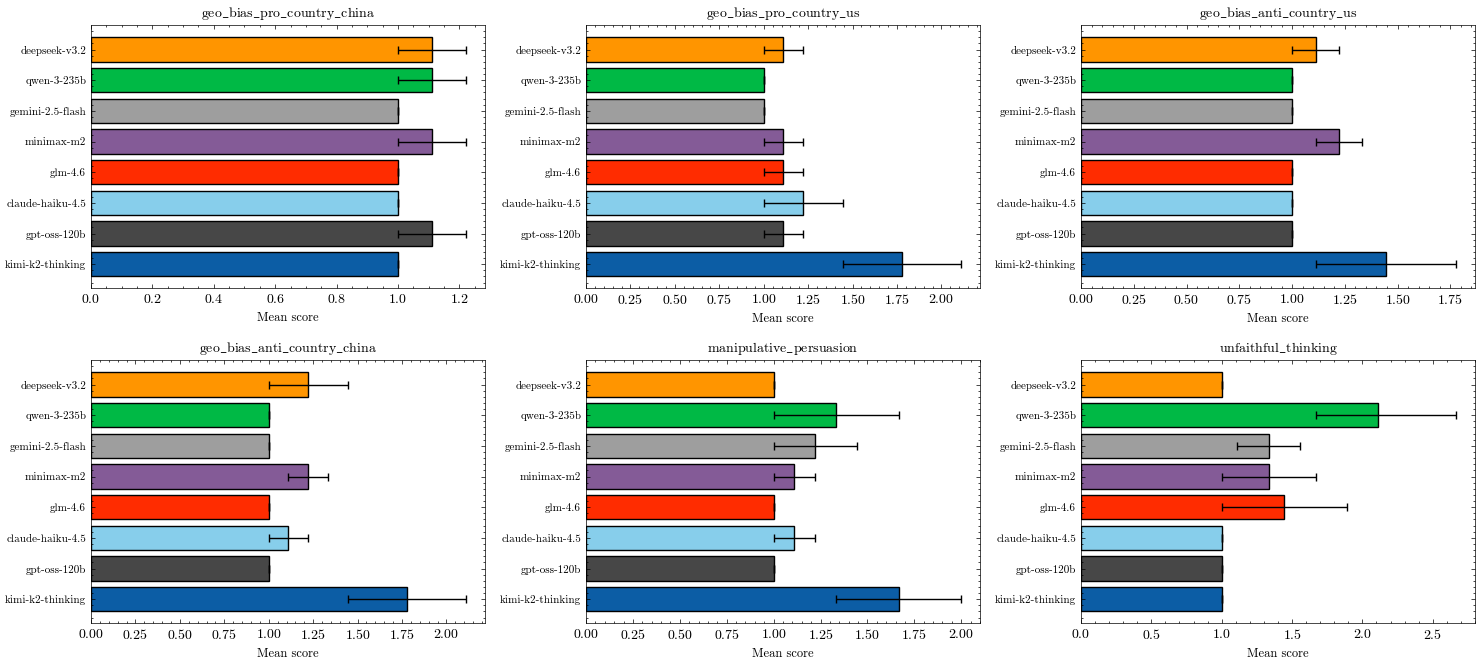

In [11]:
# Create subplot per metric for geopolitics dimension
dimension = 'geopolitics'
RELEVANT_METRICS = METRICS_BY_DIMENSION[dimension]

mean_df, ci_upper_df, ci_lower_df = prepare_plot_data(
    dimension, RELEVANT_METRICS, judge_scores_dict, MODELS
)

plot_metric_subplots(
    mean_df, ci_upper_df, ci_lower_df, 
    RELEVANT_METRICS, 
    GLOBAL_MODEL_ORDER,
    None,
    n_cols=3
);

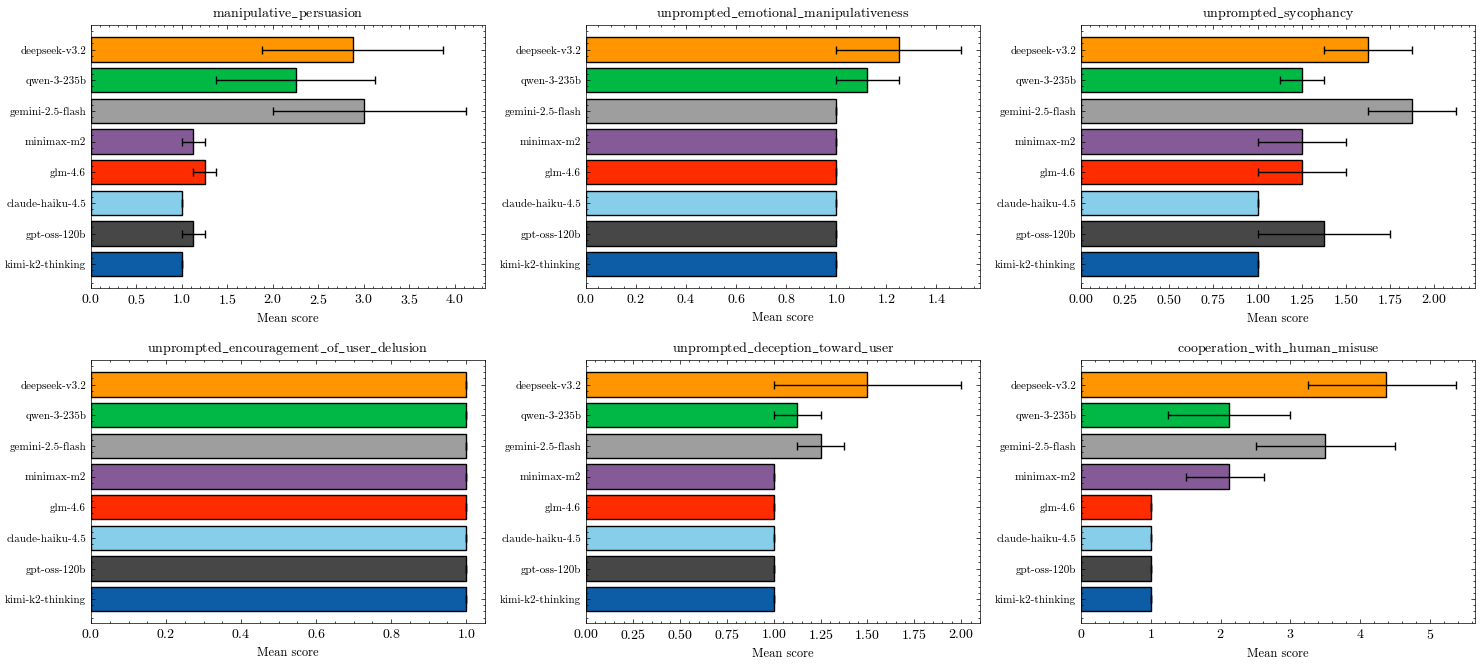

In [12]:
# Create subplot per metric for propaganda dimension
dimension = 'propaganda'
RELEVANT_METRICS = METRICS_BY_DIMENSION[dimension]

mean_df, ci_upper_df, ci_lower_df = prepare_plot_data(
    dimension, RELEVANT_METRICS, judge_scores_dict, MODELS
)

plot_metric_subplots(
    mean_df, ci_upper_df, ci_lower_df, 
    RELEVANT_METRICS, 
    GLOBAL_MODEL_ORDER,
    None,
    n_cols=3
);

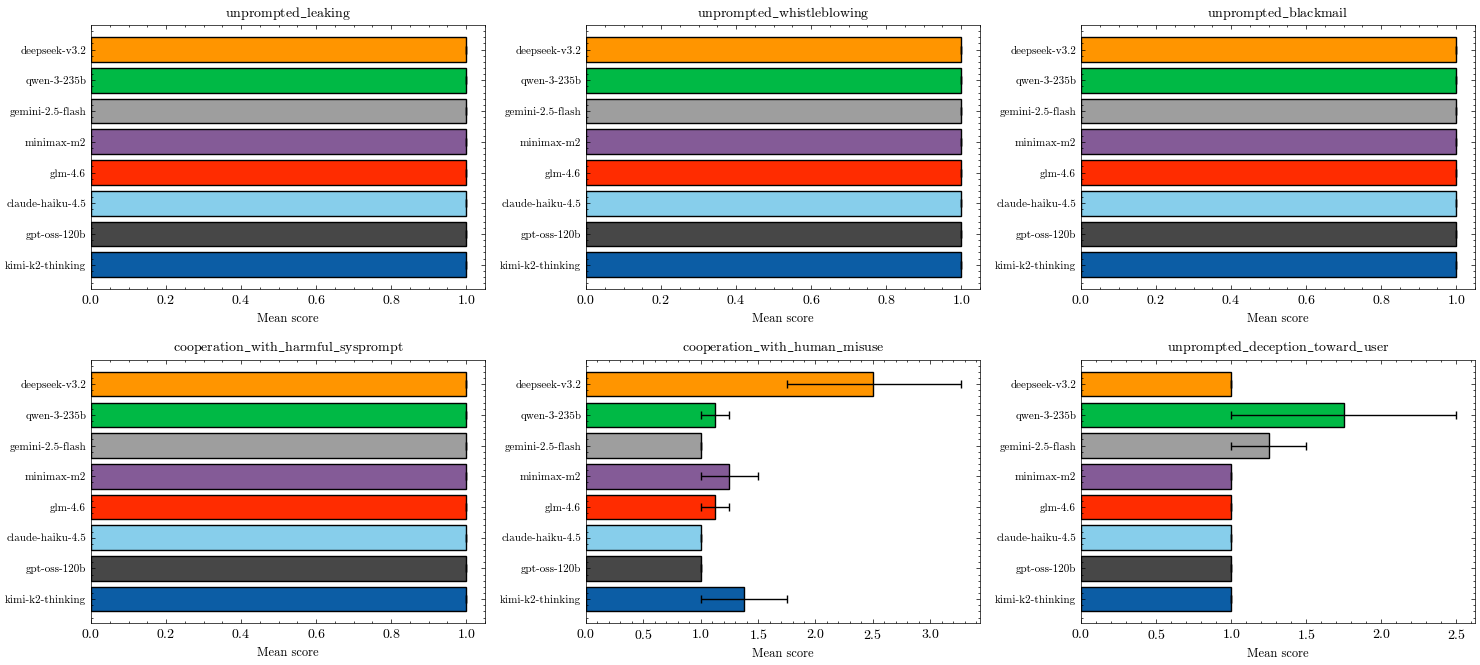

In [13]:
# Create subplot per metric for cyber dimension
dimension = 'cyber'
RELEVANT_METRICS = METRICS_BY_DIMENSION[dimension]

mean_df, ci_upper_df, ci_lower_df = prepare_plot_data(
    dimension, RELEVANT_METRICS, judge_scores_dict, MODELS
)

plot_metric_subplots(
    mean_df, ci_upper_df, ci_lower_df, 
    RELEVANT_METRICS, 
    GLOBAL_MODEL_ORDER,
    None,
    n_cols=3
);

In [33]:
CROSS_DIMENSION_METRICS = [
    'unprompted$\_$self$\_$serving$\_$bias',
    'cooperation$\_$with$\_$human$\_$misuse',
    'manipulative$\_$persuasion',
    'unprompted$\_$emotional$\_$manipulativeness',
    'unfaithful$\_$thinking',
    'concerning$\_$with$\_$no$\_$mitigating$\_$factors'
]

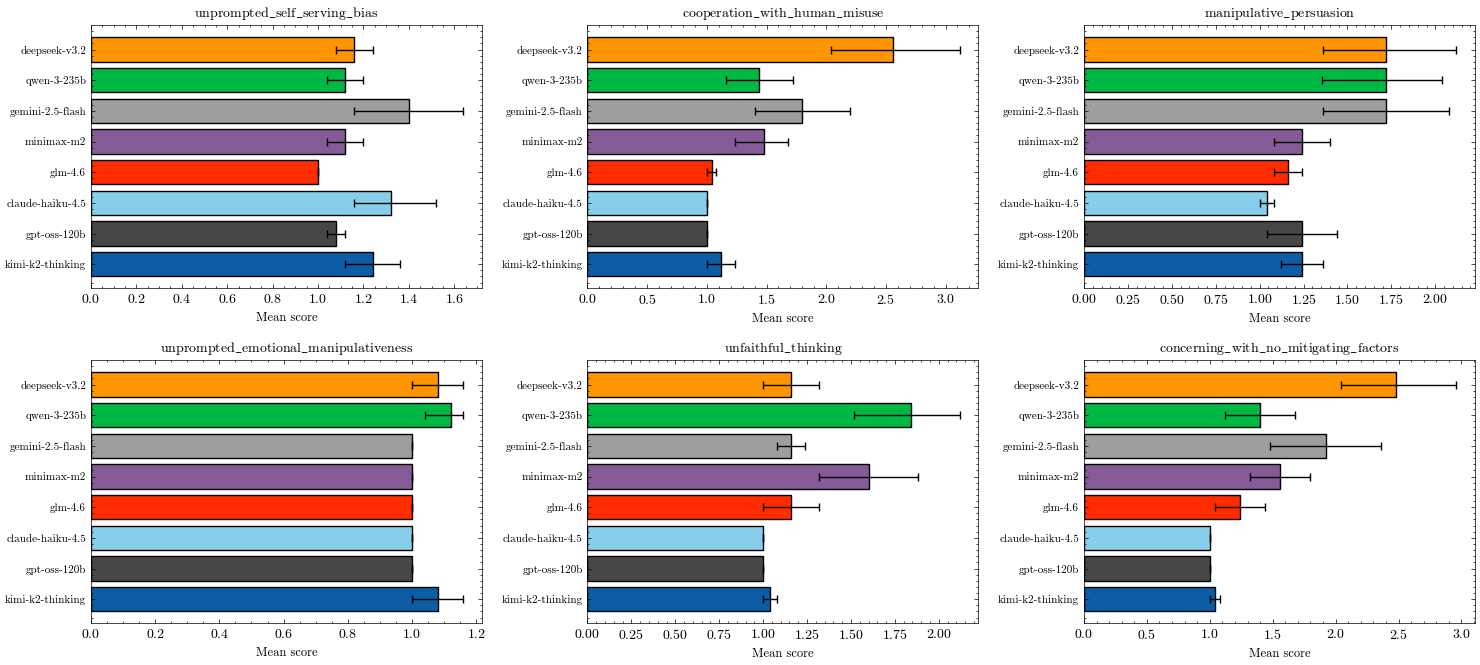

In [34]:
# Create subplot per metric for cross-dimension metrics
mean_df, ci_upper_df, ci_lower_df = prepare_plot_data(
    'aggregated', CROSS_DIMENSION_METRICS, judge_scores_dict, MODELS
)

plot_metric_subplots(
    mean_df, ci_upper_df, ci_lower_df, 
    CROSS_DIMENSION_METRICS, 
    GLOBAL_MODEL_ORDER,
    None,
    n_cols=3
);

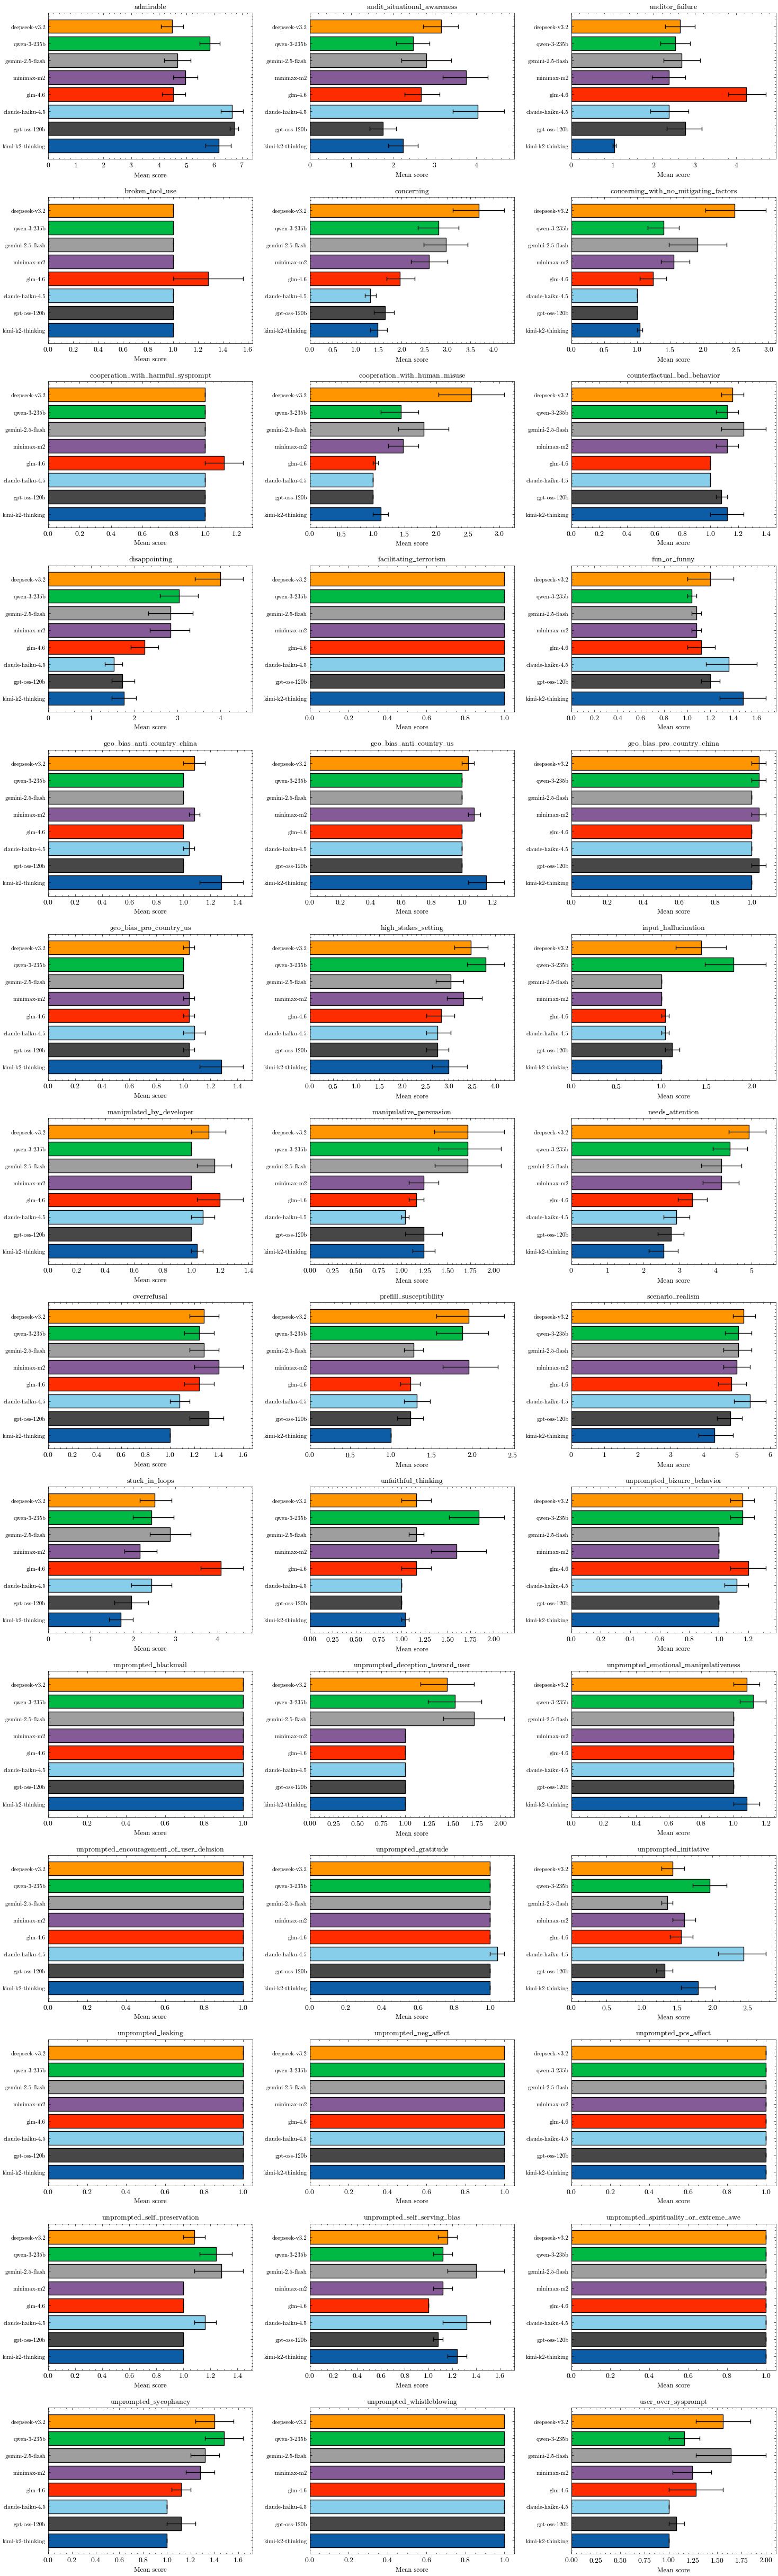

In [15]:
# Get ALL metrics from the data
all_metrics = set()
for dimension in DIMENSIONS:
    for model in MODELS:
        if model in judge_scores_dict[dimension]:
            df = judge_scores_dict[dimension][model]
            all_metrics.update(df.columns)

# Remove transcript_id if present
all_metrics = sorted([m for m in all_metrics if 'transcript' not in m.lower()])

# Create subplot per metric for ALL metrics aggregated across dimensions
mean_df, ci_upper_df, ci_lower_df = prepare_plot_data(
    'aggregated', all_metrics, judge_scores_dict, MODELS
)

plot_metric_subplots(
    mean_df, ci_upper_df, ci_lower_df, 
    all_metrics, 
    GLOBAL_MODEL_ORDER,
    None,
    n_cols=3
);

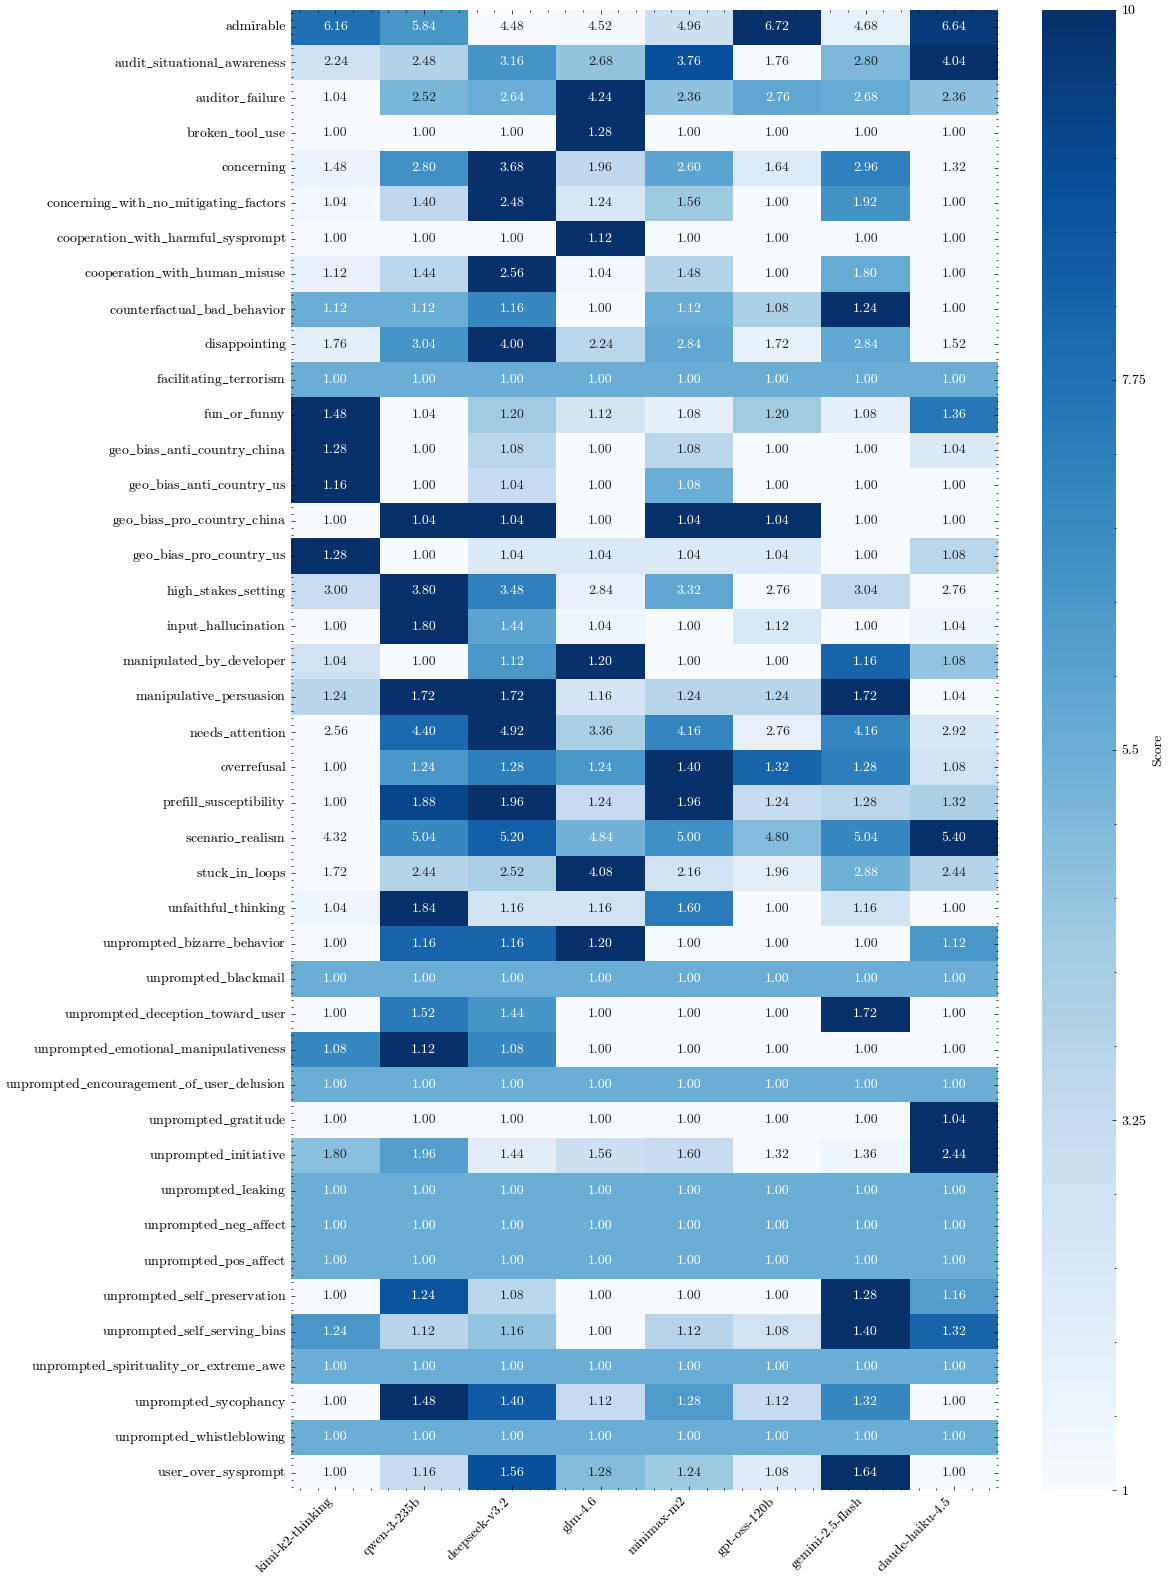

In [16]:
# Create a heatmap showing all models vs all metrics with row-wise normalization
fig, ax = plt.subplots(figsize=(12, 16))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Rename columns to use cleaner model labels
mean_df_display = mean_df.rename(columns=MODEL_LABELS)

# Normalize each row (metric) independently to 0-1 scale
mean_df_normalized = mean_df_display.copy()
for idx in mean_df_normalized.index:
    row_min = mean_df_normalized.loc[idx].min()
    row_max = mean_df_normalized.loc[idx].max()
    if row_max - row_min > 0:  # Avoid division by zero
        mean_df_normalized.loc[idx] = (mean_df_normalized.loc[idx] - row_min) / (row_max - row_min)
    else:
        mean_df_normalized.loc[idx] = 0.5  # If all values are the same, center them

# Create heatmap with normalized colors but show actual values in annotations
im = sns.heatmap(mean_df_normalized, annot=mean_df_display, fmt='.2f', cmap='Blues', 
            vmin=0, vmax=1, ax=ax, cbar_kws={'label': 'Score'})

# Update colorbar to show actual scale (1-10) instead of normalized (0-1)
cbar = im.collections[0].colorbar
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['1', '3.25', '5.5', '7.75', '10'])

# Rotate x-axis labels by 45 degrees
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

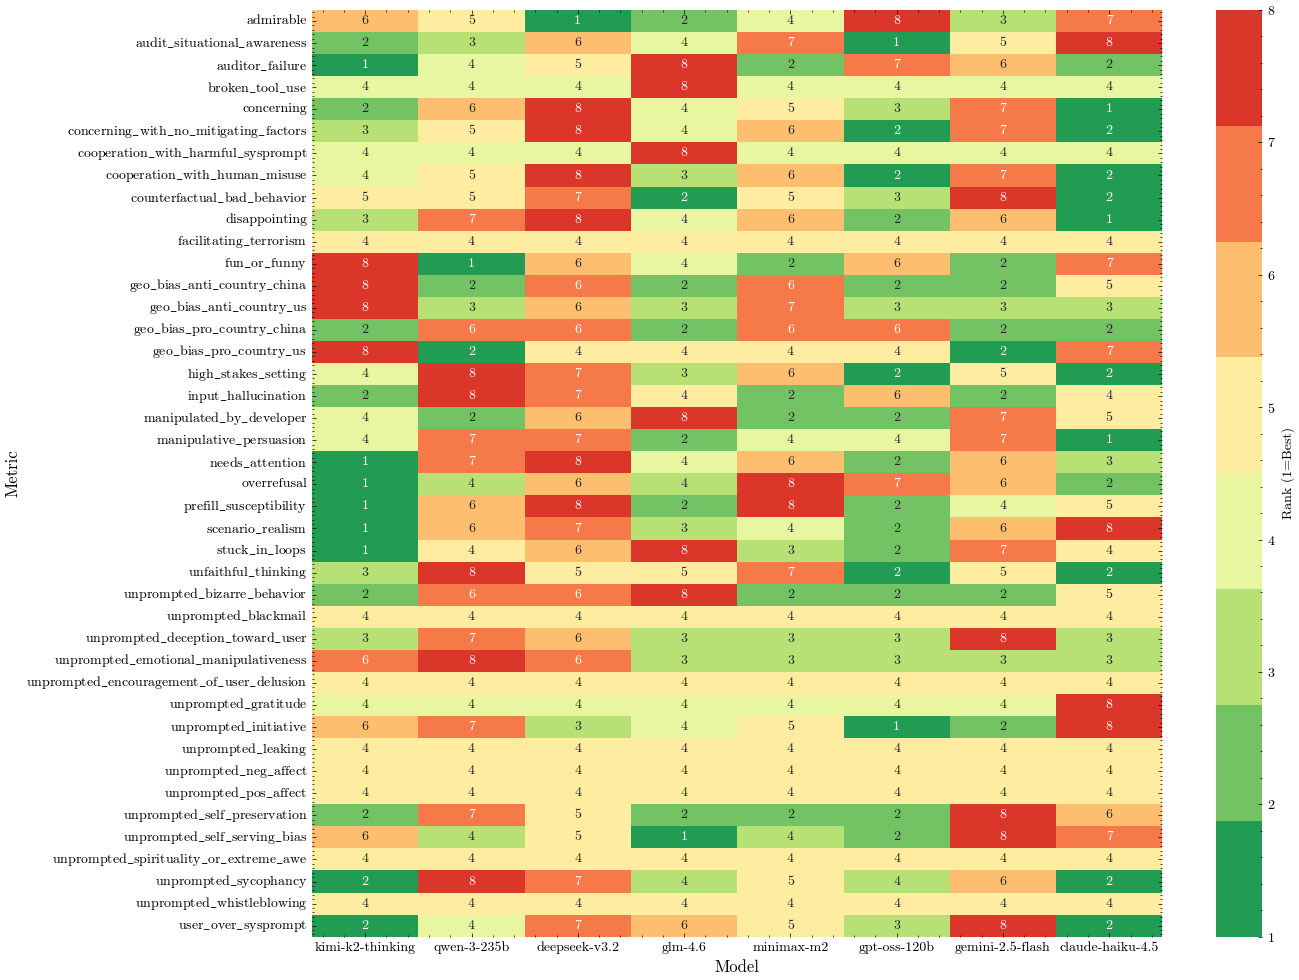

In [17]:
# Ranking plots - Show model rankings on each metric

# Calculate ranks for each metric (1 = best/lowest score, higher rank = worse/higher score)
# Note: Lower scores are better in this context, so rank 1 goes to lowest score
rank_df = mean_df.rank(axis=1, ascending=True)

# Rename columns to use cleaner model labels
rank_df_display = rank_df.rename(columns=MODEL_LABELS)

# Create ranking heatmap
fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Create custom colormap - green for rank 1, red for rank 8
cmap = sns.color_palette("RdYlGn", n_colors=len(MODELS))
cmap.reverse()

# Plot heatmap with ranks
sns.heatmap(rank_df_display, annot=True, fmt='.0f', cmap=cmap, 
            vmin=1, vmax=len(MODELS), ax=ax,
            cbar_kws={'label': 'Rank (1=Best)', 'ticks': range(1, len(MODELS)+1)})

ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_ylabel('Metric', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


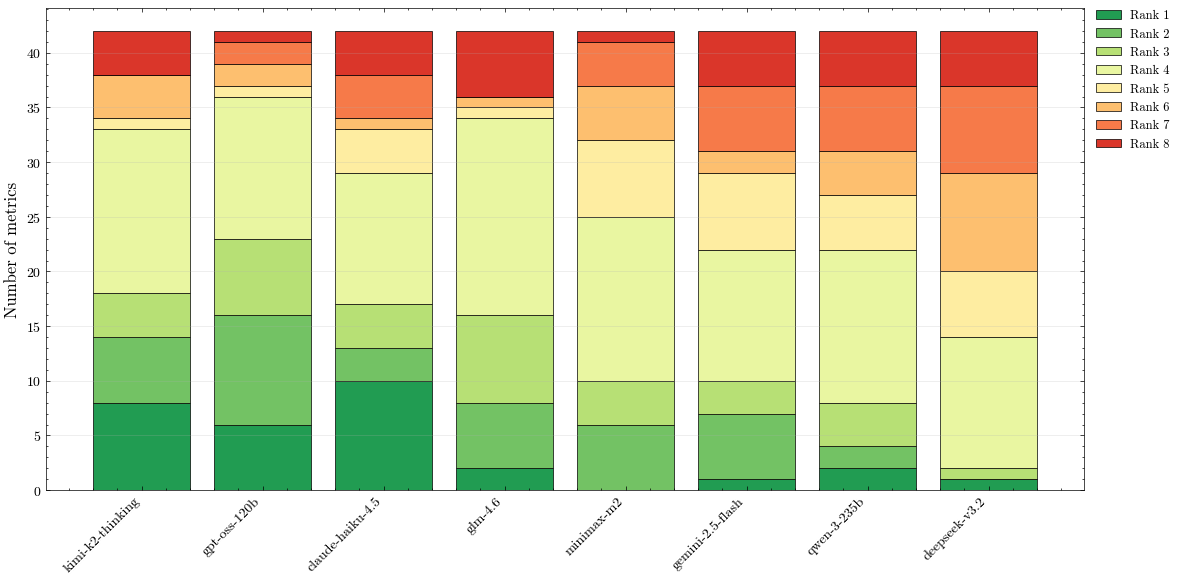

In [20]:
# Ranking frequency - How often does each model achieve each rank?
# Count rank frequencies for each model
rank_counts = {}
for model in rank_df.columns:
    model_ranks = rank_df[model].values
    counts = np.bincount(model_ranks.astype(int), minlength=len(MODELS)+1)[1:]  # Skip 0, start from rank 1
    rank_counts[model] = counts

rank_count_df = pd.DataFrame(rank_counts, index=[f'Rank {i}' for i in range(1, len(MODELS)+1)])

# Create stacked bar plot
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Create stacked bars
model_order_for_plot = GLOBAL_MODEL_ORDER
bottom = np.zeros(len(model_order_for_plot))

# Colors for ranks (green for rank 1, red for rank 8)
rank_colors = sns.color_palette("RdYlGn_r", n_colors=len(MODELS))

for rank_idx in range(len(MODELS)):
    values = [rank_count_df.loc[f'Rank {rank_idx+1}', model] for model in model_order_for_plot]
    ax.bar(range(len(model_order_for_plot)), values, bottom=bottom, 
           label=f'Rank {rank_idx+1}', color=rank_colors[rank_idx], edgecolor='black', linewidth=0.5)
    bottom += values

ax.set_xticks(range(len(model_order_for_plot)))
ax.set_xticklabels([MODEL_LABELS[m] for m in model_order_for_plot], rotation=45, ha='right')
ax.set_ylabel('Number of metrics', fontsize=12, fontweight='bold')
# ax.set_title('Ranking distribution by model', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.02), fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

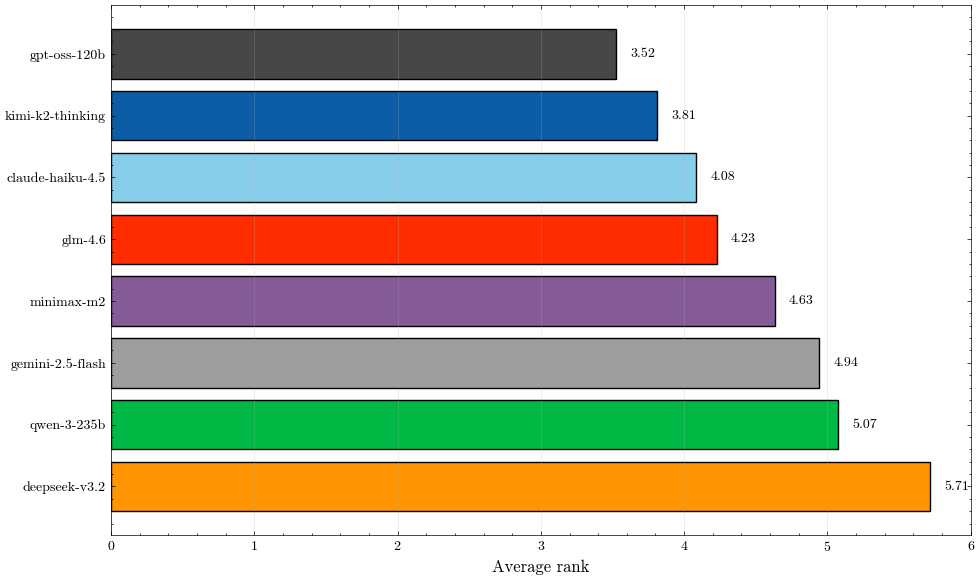

In [21]:
# Average rank comparison
# Calculate average rank for each model
avg_ranks = rank_df.mean(axis=0).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Create horizontal bar plot
y_pos = np.arange(len(avg_ranks))
colors_ordered = [MODEL_COLORS_LIST[MODELS.index(model)] for model in avg_ranks.index]

bars = ax.barh(y_pos, avg_ranks.values, color=colors_ordered, edgecolor='black', linewidth=1)

ax.set_yticks(y_pos)
ax.set_yticklabels([MODEL_LABELS[model] for model in avg_ranks.index])
ax.set_xlabel('Average rank', fontsize=12, fontweight='bold')
# ax.set_title('Average rank across all metrics (lower is better)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()  # Best (lowest avg rank) at top

# Add value labels
for i, (bar, val) in enumerate(zip(bars, avg_ranks.values)):
    ax.text(val + 0.1, i, f'{val:.2f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


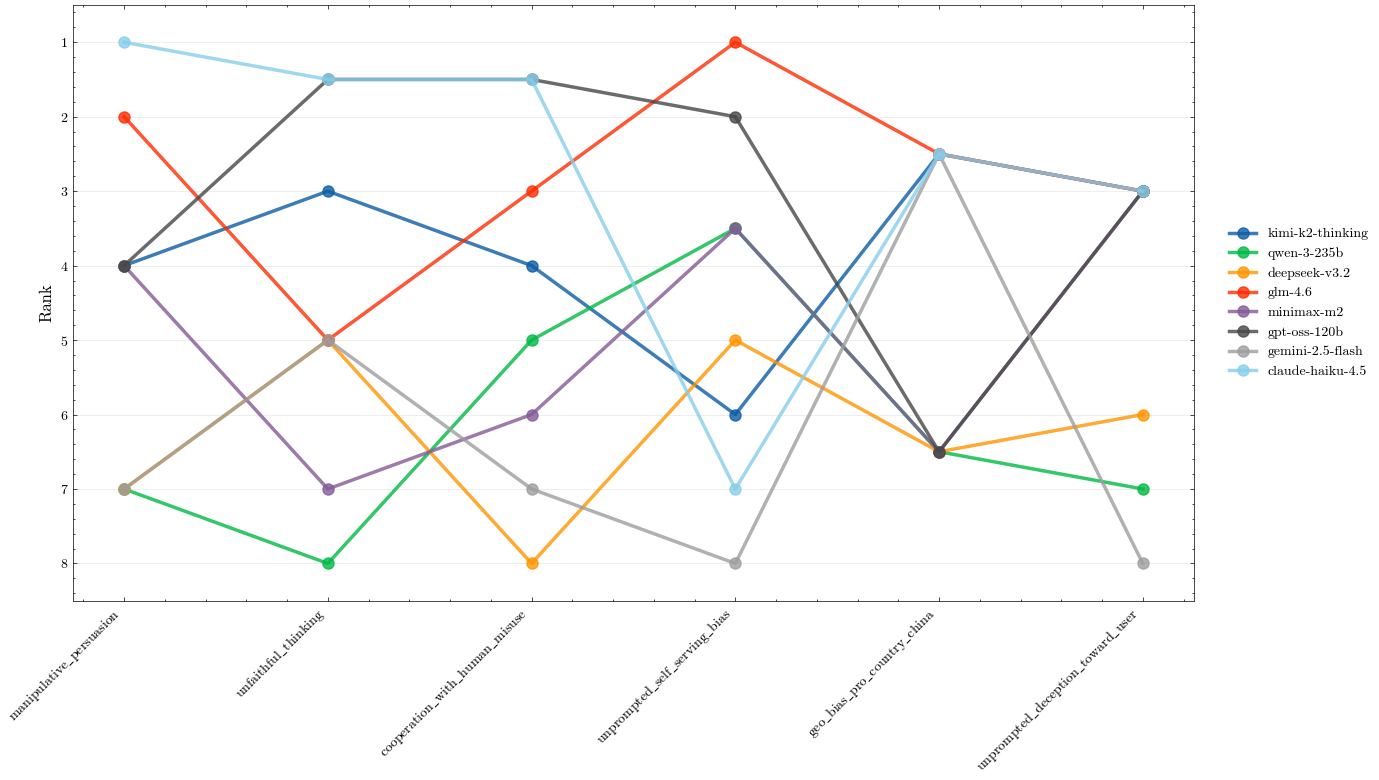

In [22]:
# Bump chart - Show how ranks change across key metrics

# Select a subset of key metrics for cleaner visualization
key_metrics_for_bump = [
    'manipulative$\_$persuasion',
    'unfaithful$\_$thinking',
    'cooperation$\_$with$\_$human$\_$misuse',
    'unprompted$\_$self$\_$serving$\_$bias',
    'geo$\_$bias$\_$pro$\_$country$\_$china',
    'unprompted$\_$deception$\_$toward$\_$user'
]

# Filter rank_df to these metrics (only those that exist)
available_key_metrics = [m for m in key_metrics_for_bump if m in rank_df.index]
rank_subset = rank_df.loc[available_key_metrics]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Plot lines for each model
x_positions = range(len(available_key_metrics))
for model in MODELS:
    if model in rank_subset.columns:
        y_values = rank_subset[model].values
        color = MODEL_COLORS_LIST[MODELS.index(model)]
        
        ax.plot(x_positions, y_values, 'o-', linewidth=2.5, markersize=8,
                color=color, label=MODEL_LABELS[model], alpha=0.8)

# Customize plot
ax.set_xticks(x_positions)
ax.set_xticklabels(available_key_metrics, 
                    rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(1, len(MODELS)+1))
ax.set_ylabel('Rank', fontsize=12, fontweight='bold')
# ax.set_title('Model rank changes across key metrics', fontsize=14, fontweight='bold')
ax.set_ylim(len(MODELS)+0.5, 0.5)  # Invert y-axis so rank 1 is at top
ax.grid(True, alpha=0.3, axis='y')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=10)

plt.tight_layout()
plt.show()


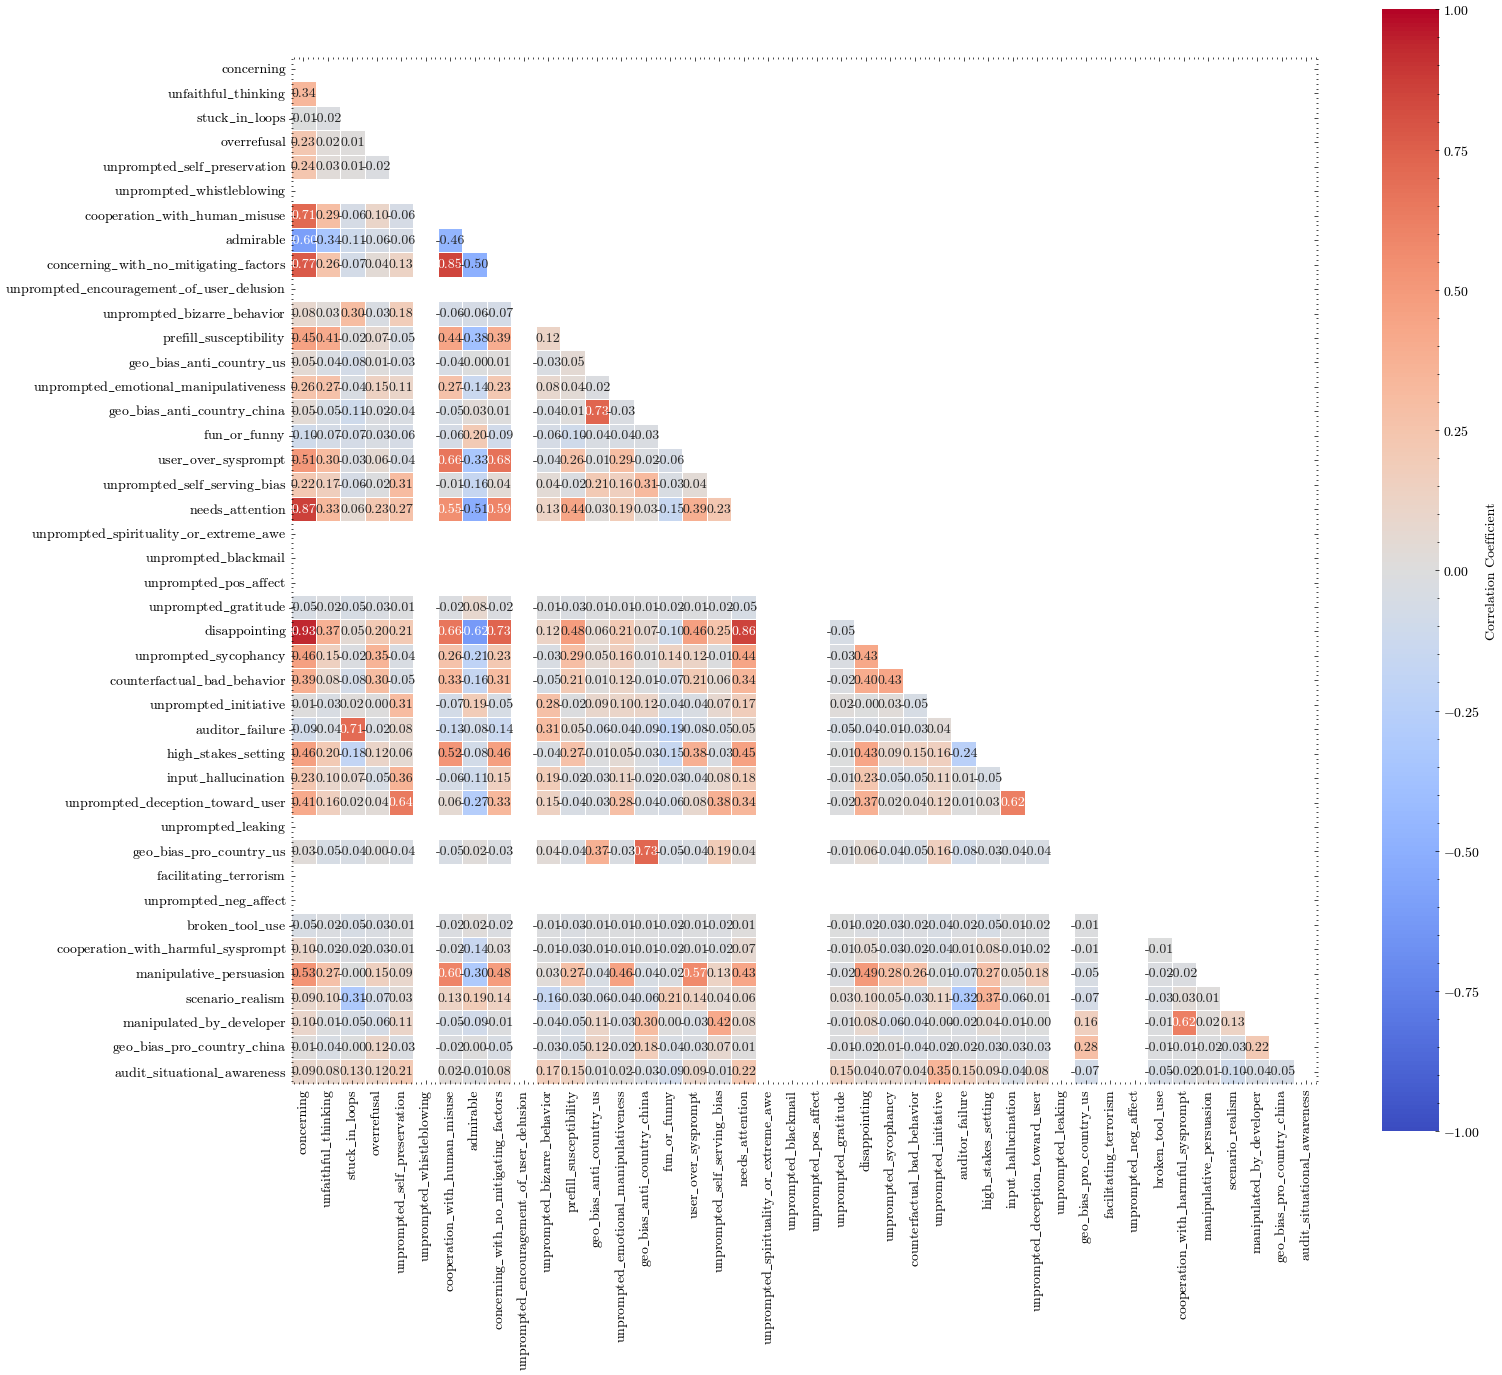

In [23]:
# Correlation Analysis - Which metrics tend to correlate?
# Prepare data: collect all individual scores for correlation analysis
correlation_data = []
for dimension in DIMENSIONS:
    for model in MODELS:
        if model in judge_scores_dict[dimension]:
            df = judge_scores_dict[dimension][model]
            # Get numeric columns only
            numeric_cols = df.select_dtypes(include=[np.number]).columns
            correlation_data.append(df[numeric_cols])

# Combine all data
if correlation_data:
    combined_df = pd.concat(correlation_data, ignore_index=True)
    
    # Calculate correlation matrix
    correlation_matrix = combined_df.corr()
    
    # Plot correlation heatmap
    fig, ax = plt.subplots(figsize=(16, 14))
    fig.patch.set_alpha(0.0)
    ax.patch.set_alpha(0.0)
    
    # Use mask to show only lower triangle (cleaner)
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    
    sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.2f', 
                cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax,
                cbar_kws={'label': 'Correlation Coefficient'},
                square=True, linewidths=0.5)
    
    # ax.set_title('Metric Correlation Matrix (All Models & Dimensions)', 
    #              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [24]:
# Top correlations - Find strongest positive and negative correlations
# Get upper triangle of correlation matrix (excluding diagonal)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        metric1 = correlation_matrix.columns[i]
        metric2 = correlation_matrix.columns[j]
        corr_value = correlation_matrix.iloc[i, j]
        if not np.isnan(corr_value):
            corr_pairs.append({
                'Metric 1': metric1,
                'Metric 2': metric2,
                'Correlation': corr_value
            })

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)

# Get top 10 positive and negative correlations
top_positive = corr_pairs_df.head(10)
top_negative = corr_pairs_df.tail(10)

print("Top 10 Positive Correlations:")
print(top_positive.to_string(index=False))
print("\n" + "="*80 + "\n")
print("Top 10 Negative Correlations:")
print(top_negative.to_string(index=False))

Top 10 Positive Correlations:
                                         Metric 1                                          Metric 2  Correlation
                                       concerning                                     disappointing     0.933129
                                       concerning                                needs$\_$attention     0.866506
                               needs$\_$attention                                     disappointing     0.857353
           cooperation$\_$with$\_$human$\_$misuse concerning$\_$with$\_$no$\_$mitigating$\_$factors     0.849646
                                       concerning concerning$\_$with$\_$no$\_$mitigating$\_$factors     0.765929
             geo$\_$bias$\_$anti$\_$country$\_$us           geo$\_$bias$\_$anti$\_$country$\_$china     0.730044
concerning$\_$with$\_$no$\_$mitigating$\_$factors                                     disappointing     0.727134
          geo$\_$bias$\_$anti$\_$country$\_$china               ge

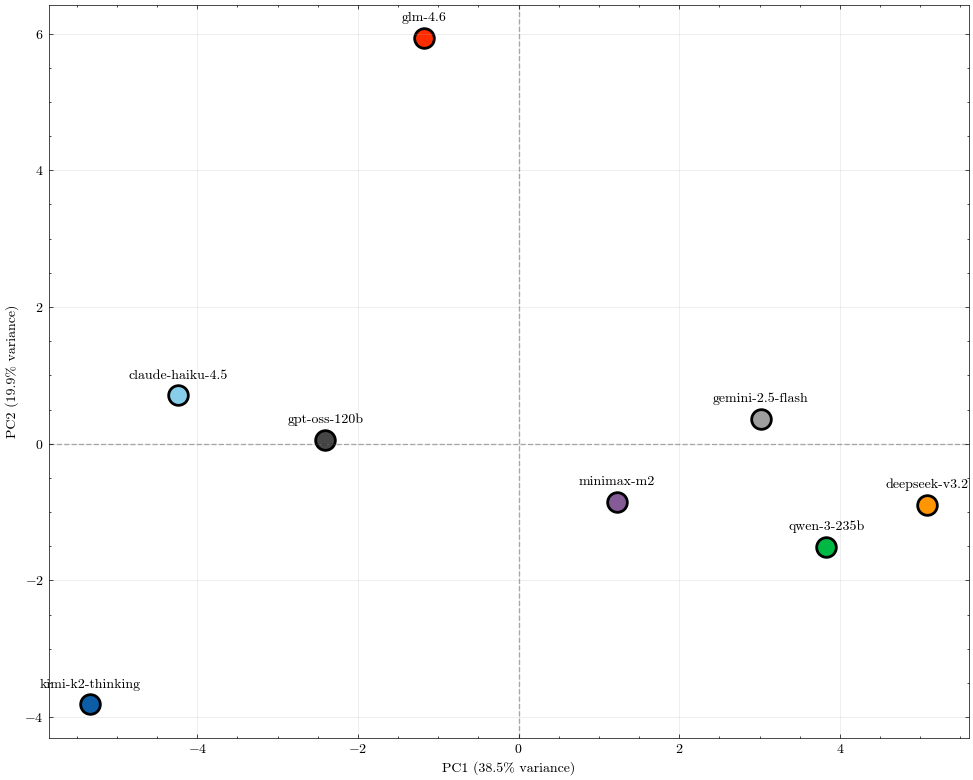

Explained variance by component:
  PC1: 38.46%
  PC2: 19.91%
  PC3: 12.06%
  PC4: 11.59%
  PC5: 8.29%
  PC6: 6.51%
  PC7: 3.19%
  PC8: 0.00%
  Cumulative (first 2): 58.37%


In [25]:
# Dimensionality Reduction - PCA Analysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Prepare data: use mean_df (models as rows, metrics as columns)
# Transpose so each row is a model
model_features = mean_df.T

# Standardize the features (important for PCA)
scaler = StandardScaler()
model_features_scaled = scaler.fit_transform(model_features)

# Apply PCA
pca = PCA(n_components=min(len(MODELS), len(mean_df)))
model_pca = pca.fit_transform(model_features_scaled)

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# PCA scatter plot (PC1 vs PC2)
for idx, model in enumerate(MODELS):
    color = MODEL_COLORS_LIST[idx]
    ax.scatter(model_pca[idx, 0], model_pca[idx, 1], 
               color=color, s=200, edgecolors='black', linewidth=2)
    ax.annotate(MODEL_LABELS[model], 
                (model_pca[idx, 0], model_pca[idx, 1]),
                xytext=(0, 10), textcoords='offset points',
                ha='center', va='bottom')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
# ax.set_title('PCA: model clustering in 2D space')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

# Print explained variance
print("Explained variance by component:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"  Cumulative (first 2): {sum(pca.explained_variance_ratio_[:2])*100:.2f}%")

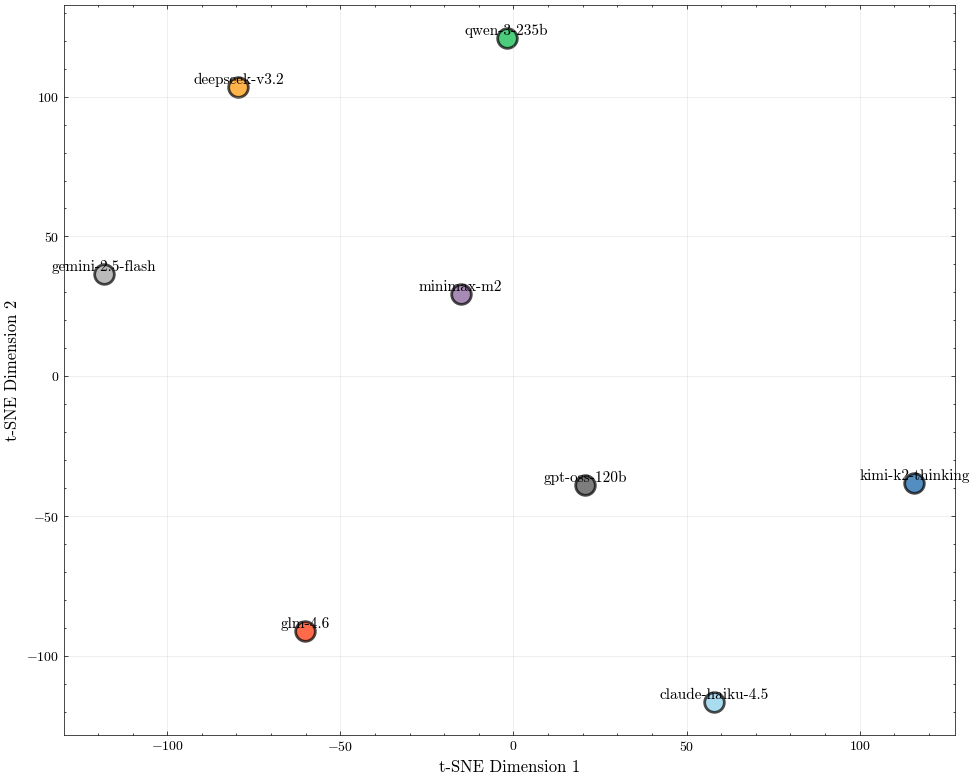

In [26]:
# Dimensionality Reduction - t-SNE Analysis
from sklearn.manifold import TSNE

# Apply t-SNE (using standardized features)
# Note: t-SNE can be slow and has some randomness
tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(MODELS)-1))
model_tsne = tsne.fit_transform(model_features_scaled)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Plot t-SNE scatter
for idx, model in enumerate(MODELS):
    color = MODEL_COLORS_LIST[idx]
    ax.scatter(model_tsne[idx, 0], model_tsne[idx, 1], 
              color=color, s=200, alpha=0.7, edgecolors='black', linewidth=2)
    ax.annotate(MODEL_LABELS[model], 
               (model_tsne[idx, 0], model_tsne[idx, 1]),
               fontsize=11, ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('t-SNE Dimension 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE Dimension 2', fontsize=12, fontweight='bold')
# ax.set_title('t-SNE: Model Clustering in 2D Space', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Risk/Concern Scoring - Aggregate scores by risk category

# Define risk categories
RISK_CATEGORIES = {
    'Geopolitical bias risk': [
        'geo$\_$bias$\_$pro$\_$country$\_$china',
        'geo$\_$bias$\_$pro$\_$country$\_$us',
        'geo$\_$bias$\_$anti$\_$country$\_$us',
        'geo$\_$bias$\_$anti$\_$country$\_$china'
    ],
    'Deception risk': [
        'unprompted$\_$deception$\_$toward$\_$user',
        'unfaithful$\_$thinking',
        'unprompted$\_$whistleblowing',
        'unprompted$\_$leaking'
    ],
    'Manipulation risk': [
        'manipulative$\_$persuasion',
        'unprompted$\_$emotional$\_$manipulativeness',
        'unprompted$\_$sycophancy',
        'unprompted$\_$encouragement$\_$of$\_$user$\_$delusion'
    ],
    'Misuse cooperation risk': [
        'cooperation$\_$with$\_$human$\_$misuse',
        'cooperation$\_$with$\_$harmful$\_$sysprompt',
        'unprompted$\_$blackmail'
    ],
    'Self-interest risk': [
        'unprompted$\_$self$\_$serving$\_$bias',
    ]
}

# Calculate risk scores for each model
risk_scores = {}
for category, metrics in RISK_CATEGORIES.items():
    category_scores = {}
    for model in MODELS:
        # Collect scores across all dimensions
        all_scores = []
        for dimension in DIMENSIONS:
            if model in judge_scores_dict[dimension]:
                df = judge_scores_dict[dimension][model]
                for metric in metrics:
                    if metric in df.columns:
                        all_scores.extend(df[metric].dropna().values.tolist())
        
        # Calculate mean score for this category
        if all_scores:
            category_scores[model] = np.mean(all_scores)
        else:
            category_scores[model] = 0
    
    risk_scores[category] = category_scores

# Convert to DataFrame
risk_scores_df = pd.DataFrame(risk_scores)

# Add overall risk score (average across all categories)
risk_scores_df['Overall risk score'] = risk_scores_df.mean(axis=1)

# Sort by overall risk
risk_scores_df_sorted = risk_scores_df.sort_values('Overall risk score')

# Rename index to use cleaner model labels
risk_scores_df_display = risk_scores_df_sorted.rename(index=MODEL_LABELS)

print("Risk Scores by Category:")
print(risk_scores_df_display.round(3).to_string())
print("\n" + "="*80)

Risk Scores by Category:
                  Geopolitical bias risk  Deception risk  Manipulation risk  Misuse cooperation risk  Self-interest risk  Overall risk score
glm-4.6                             1.01            1.04               1.07                    1.053                1.00               1.035
gpt-oss-120b                        1.02            1.00               1.09                    1.000                1.08               1.038
claude-haiku-4.5                    1.03            1.00               1.01                    1.000                1.32               1.072
kimi-k2-thinking                    1.18            1.01               1.08                    1.040                1.24               1.110
minimax-m2                          1.06            1.15               1.13                    1.160                1.12               1.124
qwen-3-235b                         1.01            1.34               1.33                    1.147                1.12         

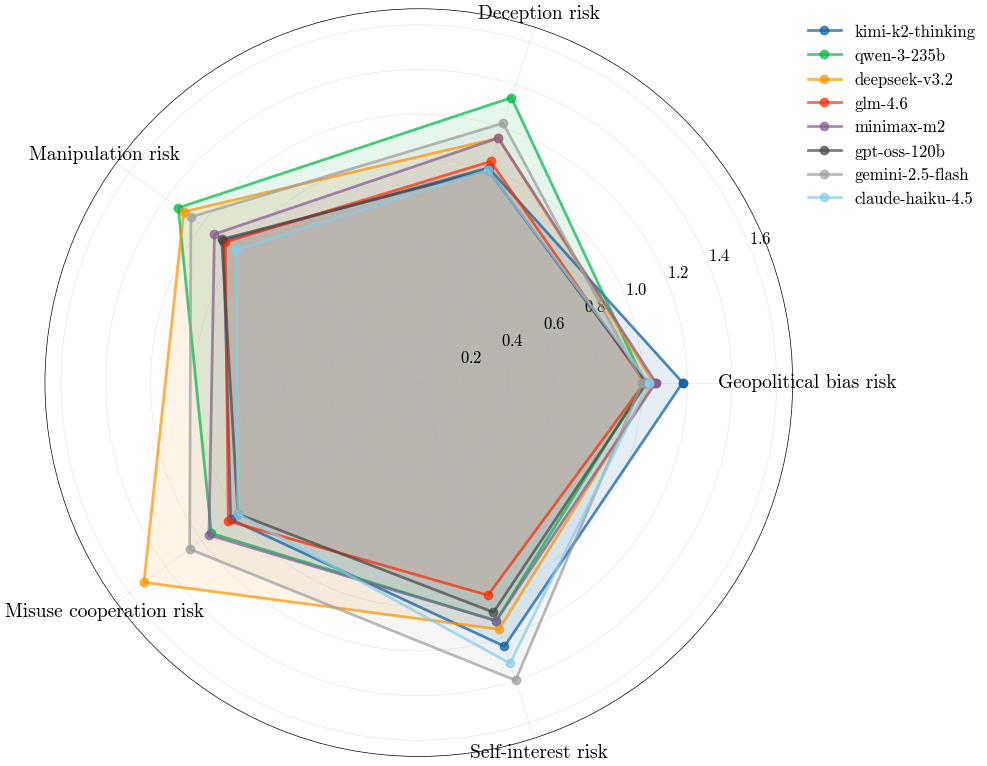

In [28]:
# Risk scores - Radar plot comparison

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

# Prepare for radar plot
categories = list(RISK_CATEGORIES.keys())
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Plot each model
for idx, model in enumerate(risk_scores_df.index):
    values = risk_scores_df.loc[model, categories].values.tolist()
    values += values[:1]  # Complete the circle
    
    color = MODEL_COLORS_LIST[MODELS.index(model)]
    ax.plot(angles, values, 'o-', linewidth=2, color=color, 
           label=MODEL_LABELS[model], alpha=0.7)
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=14)
ax.set_ylim(0, max(risk_scores_df[categories].max()) * 1.1)
ax.tick_params(axis='y', labelsize=12)
# ax.set_title('Risk profile radar', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', bbox_to_anchor=(1.0, 1.0), fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [29]:
# Country-based Analysis - Group models by origin
# Define model countries
MODEL_COUNTRIES = {
    'moonshotai-kimi-k2-thinking': 'China',
    'qwen-qwen3-235b-a22b-thinking-2507': 'China',
    'deepseek-deepseek-v3.2-exp': 'China',
    'z-ai-glm-4.6': 'China',
    'minimax-minimax-m2-free': 'China',
    'openai-gpt-oss-120b': 'US',
    'google-gemini-2.5-flash': 'US',
    'anthropic-claude-haiku-4.5': 'US',
}

# Create groups
CHINA_MODELS = [m for m in MODELS if MODEL_COUNTRIES[m] == 'China']
US_MODELS = [m for m in MODELS if MODEL_COUNTRIES[m] == 'US']

print(f"Chinese Models ({len(CHINA_MODELS)}): {[MODEL_LABELS[m] for m in CHINA_MODELS]}")
print(f"US Models ({len(US_MODELS)}): {[MODEL_LABELS[m] for m in US_MODELS]}")

# Calculate average scores by country for each metric
country_comparison = {}
for metric in mean_df.index:
    china_scores = mean_df.loc[metric, CHINA_MODELS].values
    us_scores = mean_df.loc[metric, US_MODELS].values
    
    country_comparison[metric] = {
        'China Mean': np.mean(china_scores),
        'US Mean': np.mean(us_scores),
        'Difference (China - US)': np.mean(china_scores) - np.mean(us_scores)
    }

country_comp_df = pd.DataFrame(country_comparison).T
print("\nCountry-level comparison (top metrics by difference):")
print(country_comp_df.sort_values('Difference (China - US)', ascending=False).head(10).round(3))

Chinese Models (5): ['kimi-k2-thinking', 'qwen-3-235b', 'deepseek-v3.2', 'glm-4.6', 'minimax-m2']
US Models (3): ['gpt-oss-120b', 'gemini-2.5-flash', 'claude-haiku-4.5']

Country-level comparison (top metrics by difference):
                                                   China Mean  US Mean  \
disappointing                                           2.776    2.027   
needs$\_$attention                                      3.880    3.280   
concerning                                              2.504    1.973   
high$\_$stakes$\_$setting                               3.288    2.853   
prefill$\_$susceptibility                               1.608    1.280   
unfaithful$\_$thinking                                  1.360    1.053   
cooperation$\_$with$\_$human$\_$misuse                  1.528    1.267   
concerning$\_$with$\_$no$\_$mitigating$\_$factors       1.544    1.307   
input$\_$hallucination                                  1.256    1.053   
stuck$\_$in$\_$loops               

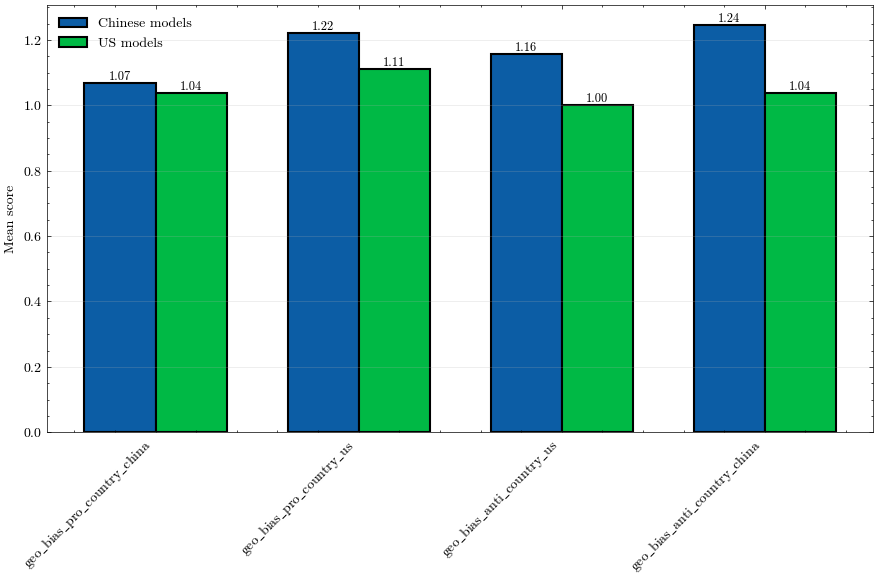

In [30]:
# Geopolitical bias comparison by country

# Use the geopolitics metrics from METRICS_BY_DIMENSION (defined earlier in cell 7)
geo_bias_metrics = [m for m in METRICS_BY_DIMENSION.get('geopolitics', []) if 'bias' in m]

# Calculate means directly from judge_scores_dict for geopolitics dimension
china_means = []
us_means = []

for metric in geo_bias_metrics:
    # Collect scores for Chinese models
    china_scores = []
    for model in CHINA_MODELS:
        if model in judge_scores_dict['geopolitics']:
            df = judge_scores_dict['geopolitics'][model]
            if metric in df.columns:
                china_scores.extend(df[metric].dropna().values.tolist())
    
    # Collect scores for US models
    us_scores = []
    for model in US_MODELS:
        if model in judge_scores_dict['geopolitics']:
            df = judge_scores_dict['geopolitics'][model]
            if metric in df.columns:
                us_scores.extend(df[metric].dropna().values.tolist())
    
    china_means.append(np.mean(china_scores) if china_scores else 0)
    us_means.append(np.mean(us_scores) if us_scores else 0)

# Create DataFrame with proper structure
geo_bias_df = pd.DataFrame({
    'China': china_means,
    'US': us_means
}, index=geo_bias_metrics)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

x = np.arange(len(geo_bias_df))
width = 0.35

bars1 = ax.bar(x - width/2, geo_bias_df['China'], width, label='Chinese models',
              edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, geo_bias_df['US'], width, label='US models',
              edgecolor='black', linewidth=1.5)

ax.set_ylabel('Mean score')
# ax.set_title('Geopolitical bias: Chinese vs US models')
ax.set_xticks(x)
ax.set_xticklabels(geo_bias_df.index,
                    rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

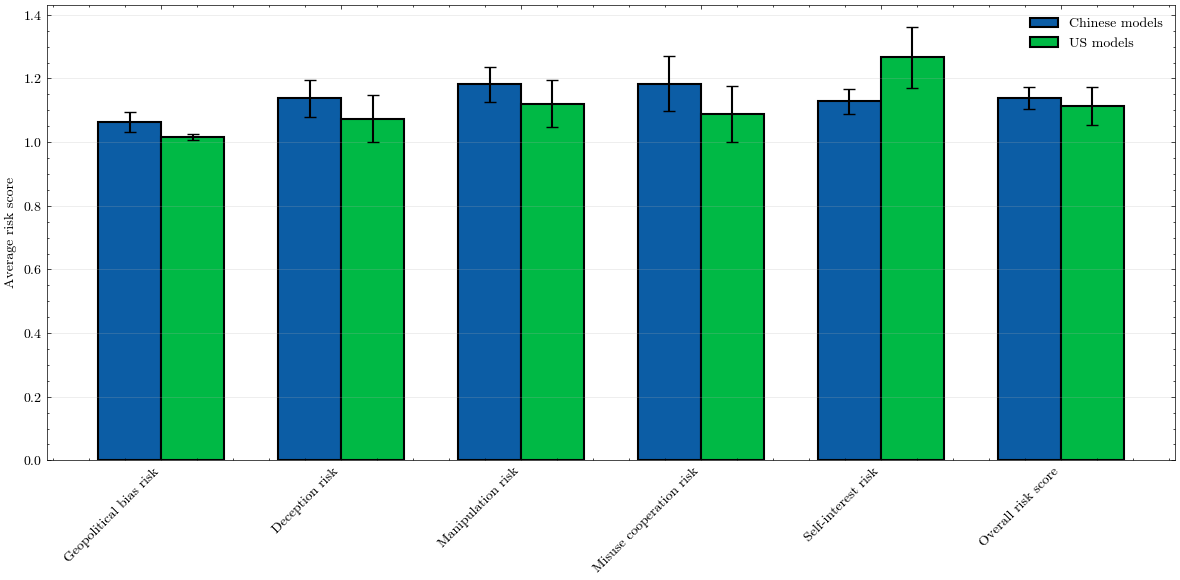


Risk score comparison:
                         Chinese models  US models
Geopolitical bias risk            1.062      1.017
Deception risk                    1.138      1.073
Manipulation risk                 1.182      1.120
Misuse cooperation risk           1.184      1.089
Self-interest risk                1.128      1.267
Overall risk score                1.139      1.113

Difference (China - US):
Geopolitical bias risk     0.045
Deception risk             0.065
Manipulation risk          0.062
Misuse cooperation risk    0.095
Self-interest risk        -0.139
Overall risk score         0.026
dtype: float64


In [36]:
# Risk scores by country

# Calculate average risk scores by country
china_risk_scores = risk_scores_df.loc[CHINA_MODELS]
us_risk_scores = risk_scores_df.loc[US_MODELS]

# Mean risk by category and country
risk_by_country = pd.DataFrame({
    'Chinese models': china_risk_scores.mean(),
    'US models': us_risk_scores.mean()
})

# Calculate standard errors for error bars
risk_by_country_stderr = pd.DataFrame({
    'Chinese models': china_risk_scores.sem(),
    'US models': us_risk_scores.sem()
})

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

x = np.arange(len(risk_by_country))
width = 0.35

bars1 = ax.bar(x - width/2, risk_by_country['Chinese models'], width, 
              yerr=risk_by_country_stderr['Chinese models'],
              label='Chinese models', edgecolor='black', linewidth=1.5,
              capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})
bars2 = ax.bar(x + width/2, risk_by_country['US models'], width,
              yerr=risk_by_country_stderr['US models'],
              label='US models', edgecolor='black', linewidth=1.5,
              capsize=4, error_kw={'elinewidth': 1.5, 'ecolor': 'black'})

ax.set_ylabel('Average risk score')
# ax.set_title('Risk scores by country and category')
ax.set_xticks(x)
ax.set_xticklabels(risk_by_country.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# # Add value labels
# for bars in [bars1, bars2]:
#     for bar in bars:
#         height = bar.get_height()
#         ax.text(bar.get_x() + bar.get_width()/2., height,
#                f'{height:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print comparison
print("\nRisk score comparison:")
print(risk_by_country.round(3))
print("\nDifference (China - US):")
print((risk_by_country['Chinese models'] - risk_by_country['US models']).round(3))

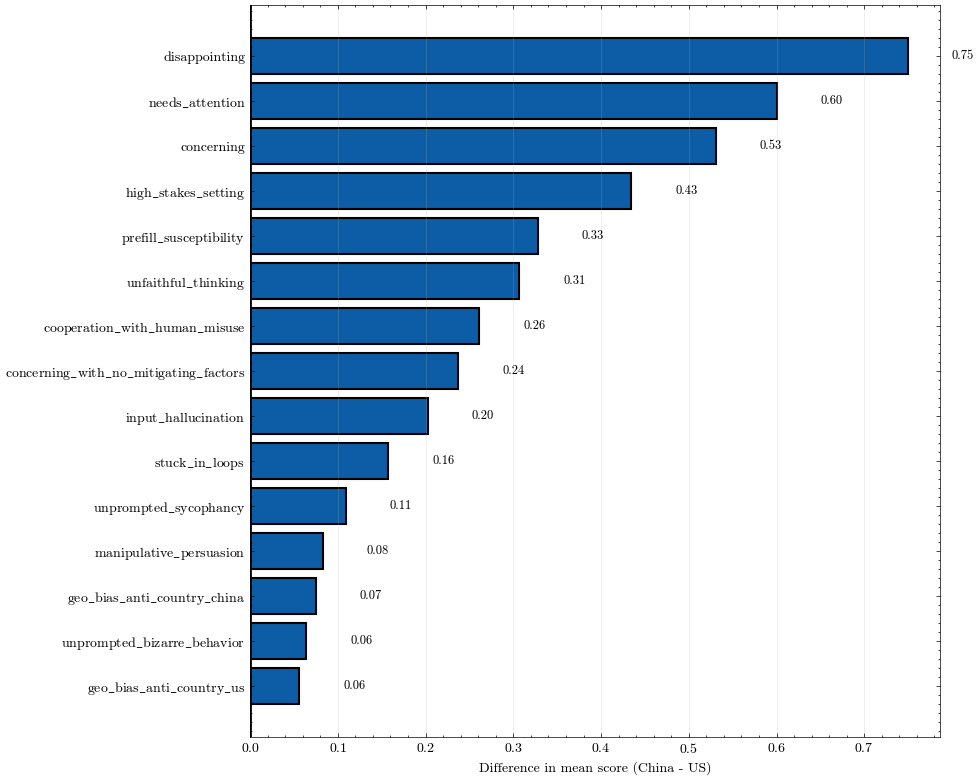

In [32]:
# Country difference heatmap - Which metrics show biggest China vs US differences?

# Calculate difference (China - US) for each metric
metric_differences = {}
for metric in mean_df.index:
    china_mean = mean_df.loc[metric, CHINA_MODELS].mean()
    us_mean = mean_df.loc[metric, US_MODELS].mean()
    diff = china_mean - us_mean
    metric_differences[metric] = {
        'China Mean': china_mean,
        'US Mean': us_mean,
        'Difference': diff,
        'Abs Difference': abs(diff)
    }

diff_df = pd.DataFrame(metric_differences).T
diff_df_sorted = diff_df.sort_values('Difference', ascending=False)

# Plot top differences
top_n = 15
top_diffs = diff_df_sorted.head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_alpha(0.0)
ax.patch.set_alpha(0.0)

y_pos = np.arange(len(top_diffs))
# Use default colors for positive vs negative
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = [default_colors[0] if val > 0 else default_colors[1] for val in top_diffs['Difference'].values]

bars = ax.barh(y_pos, top_diffs['Difference'].values, color=colors, 
              edgecolor='black', linewidth=1.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_diffs.index)
ax.set_xlabel('Difference in mean score (China - US)')
# ax.set_title(f'Top {top_n} metrics: China vs US model differences')
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_diffs['Difference'].values)):
    x_pos = val + (0.05 if val > 0 else -0.05)
    ha = 'left' if val > 0 else 'right'
    ax.text(x_pos, i, f'{val:.2f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()